In [ ]:
! pip install -q sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 2.7 MB/s eta 0:00:00


# Load subject mapping

In [ ]:
from datasets import load_dataset

podcasts_ds = load_dataset(
    "ptrdvn/gaelic-bench",
    "podcasts",
    split="test",
).remove_columns(["gd_audio"])

subject_map = {x["page_id"]: x["subject_type"] for x in podcasts_ds}

README.md: 0.00B [00:00, ?B/s]

podcasts/test-00000-of-00009.parquet:   0%|          | 0.00/272M [00:00<?, ?B/s]

podcasts/test-00001-of-00009.parquet:   0%|          | 0.00/395M [00:00<?, ?B/s]

podcasts/test-00002-of-00009.parquet:   0%|          | 0.00/487M [00:00<?, ?B/s]

podcasts/test-00003-of-00009.parquet:   0%|          | 0.00/300M [00:00<?, ?B/s]

...

podcasts/test-00005-of-00009.parquet:   0%|          | 0.00/418M [00:00<?, ?B/s]

podcasts/test-00006-of-00009.parquet:   0%|          | 0.00/443M [00:00<?, ?B/s]

podcasts/test-00007-of-00009.parquet:   0%|          | 0.00/469M [00:00<?, ?B/s]

podcasts/test-00008-of-00009.parquet:   0%|          | 0.00/504M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/908 [00:00<?, ? examples/s]

# Get model name mapping

In [ ]:
model_map = {
 'gpt-4.1-nano-2025-04-14': 'GPT 4.1 Nano',
 'claude-haiku-4-5-20251001': 'Claude Haiku 4.5',
 'OpenAI/gpt-oss-20B': 'GPT OSS 20B',
 'gpt-4o-mini-2024-07-18': 'GPT 4o Mini',
 'gpt-4.1-mini-2025-04-14': 'GPT 4.1 Mini',
 'openai/gpt-oss-120b': 'GPT OSS 120B',
 'gpt-5-nano-2025-08-07': 'GPT 5 Nano',
 'deepseek-ai/DeepSeek-R1': 'Deepseek R1',
 'meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8': 'Llama 4 Maverick',
 'zai-org/GLM-4.7': 'GLM 4.7',
 'gpt-4o-2024-08-06': 'GPT 4o',
 'gpt-4.1-2025-04-14': 'GPT 4.1',
 'gpt-5.2-2025-12-11': 'GPT 5.2',
 'gpt-5-mini-2025-08-07': 'GPT 5 Mini',
 'claude-opus-4-6': 'Claude Opus 4.6',
 'gemini-2.5-flash': 'Gemini 2.5 Flash',
 'gpt-5-2025-08-07': 'GPT 5',
 'gemini-3-pro-preview': 'Gemini 3 Pro Preview',
 'gemini-3-flash-preview': 'Gemini 3 Flash Preview'}

# Analyse translations

In [ ]:
import pandas as pd

translation_en_to_gd_df = pd.read_csv("/content/translation_en_to_gd_results.csv")
translation_gd_to_en_df = pd.read_csv("/content/translation_gd_to_en_results.csv")

translation_en_to_gd_df["subject_type"] = translation_en_to_gd_df["page_id"].apply(lambda x: subject_map[str(x)])
translation_gd_to_en_df["subject_type"] = translation_gd_to_en_df["page_id"].apply(lambda x: subject_map[str(x)])

In [ ]:
from sacrebleu.metrics import BLEU, CHRF, TER
from tqdm.auto import tqdm

bleu = BLEU()
chrf = CHRF()

gold_translation_col = "gold_translation"

def get_translation_results(df):
    model_cols = sorted(set(c for c in df.columns if c.startswith("translation_text")))

    results = {}
    for model_col in tqdm(model_cols):
        clean_model_name = model_map[model_col.split(" - ")[-1]]

        model_df = df[[model_col, gold_translation_col]].dropna()

        if len(model_df) < 1:
            continue

        model_translations = model_df[model_col].tolist()
        gold_translation = [[x] for x in model_df[gold_translation_col]]

        results[clean_model_name] = {}
        results[clean_model_name]["BLEU"] = bleu.corpus_score(model_translations, gold_translation).score
        results[clean_model_name]["CHRF"] = chrf.corpus_score(model_translations, gold_translation).score

    return results

get_subj_level_results = lambda df: {
    subj_name: get_translation_results(
        subj_df
    ) for subj_name, subj_df in df.groupby("subject_type")
}

en_to_gd_results = get_translation_results(translation_en_to_gd_df)
gd_to_en_results = get_translation_results(translation_gd_to_en_df)

en_to_gd_subject_results = get_subj_level_results(translation_en_to_gd_df)
gd_to_en_subject_results = get_subj_level_results(translation_gd_to_en_df)

  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]

...

  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

In [ ]:
pd.DataFrame(en_to_gd_results).T.join(
    pd.DataFrame(gd_to_en_results).T,
    lsuffix="_en_to_gd",
    rsuffix="_gd_to_en",
).sort_values("BLEU_en_to_gd", ascending=False).round(2)

,BLEU_en_to_gd,CHRF_en_to_gd,BLEU_gd_to_en,CHRF_gd_to_en
Gemini 3 Flash Preview,71.47,79.07,71.75,77.38
Gemini 3 Pro Preview,65.56,78.57,73.41,78.20
Gemini 2.5 Flash,65.53,74.72,74.36,77.58
GPT 4.1,65.41,74.62,66.60,72.77
Deepseek R1,62.12,71.84,75.28,77.73
GPT 5.2,61.19,72.16,71.02,76.18
GPT 5,56.94,70.27,70.27,75.82
Claude Opus 4.6,53.16,69.34,70.37,77.38
GPT 4o,52.39,67.83,68.73,74.80
GPT 5 Mini,49.19,60.93,69.58,73.34


In [ ]:
def get_subj_level_results(subject_results):

    flattened_subj_translation_results = {}

    for subj_name, subj_results in subject_results.items():
        flattened_subj_translation_results[subj_name] = {}
        for model_name, model_results in subj_results.items():
            for metric_name, metric_value in model_results.items():
                flattened_subj_translation_results[subj_name][(metric_name, model_name)] = metric_value

    return pd.DataFrame(flattened_subj_translation_results)

In [ ]:
get_subj_level_results(en_to_gd_subject_results).round(1).sort_index(level=1)

,,Folklore,Gaelic,History,Nature,Pastimes,People,Places
BLEU,Claude Haiku 4.5,35.0,36.0,36.0,48.7,35.9,48.7,47.5
CHRF,Claude Haiku 4.5,60.3,56.7,59.3,64.8,62.2,65.8,70.1
BLEU,Claude Opus 4.6,47.5,42.7,51.0,61.9,43.2,61.0,62.2
CHRF,Claude Opus 4.6,69.9,62.1,69.3,77.4,70.4,77.5,79.5
BLEU,Deepseek R1,68.2,60.1,59.6,64.4,53.4,68.9,66.2
CHRF,Deepseek R1,74.8,69.0,71.8,76.1,72.8,76.6,79.6
BLEU,GPT 4.1,59.6,46.3,61.4,56.2,46.1,55.1,63.0
CHRF,GPT 4.1,71.8,62.7,74.6,70.1,70.6,72.6,77.6
BLEU,GPT 4.1 Mini,49.4,45.6,35.6,41.8,42.3,43.2,45.6
CHRF,GPT 4.1 Mini,61.0,62.3,58.0,62.2,65.6,61.5,65.2


# Analyse closed question answering

In [ ]:
import pandas as pd
from glob import glob

closed_qa_aggregate_results = {}

for path in glob("/content/closedqa_*.csv"):
    lang = path.split("/")[-1].split(".")[0].split()[-1].split("_")[-1]
    df = pd.read_csv(path)

    baseline_cols = [c for c in df.columns if c.endswith("_baseline")]
    model_cols = [c[:-len("_baseline")] for c in df.columns if c.endswith("_baseline")]

    results = {}

    for model_col, baseline_col in zip(model_cols, baseline_cols):
        clean_model_name = model_col.split()[-1]
        if clean_model_name not in model_map.keys():
            continue

        results[model_map[clean_model_name]] = {
            "model_acc": (df[model_col] == df["correct_ans"]).mean(),
            "baseline_acc": (df[baseline_col] == df["correct_ans"]).mean(),
        }

    closed_qa_aggregate_results[lang] = pd.DataFrame(results).T

In [ ]:
closed_qa_final_results_df = (
    closed_qa_aggregate_results["gd"] * 100
).join(
    closed_qa_aggregate_results["en"] * 100,
    lsuffix="_gd",
    rsuffix="_en",
).sort_values(
    "model_acc_gd",
    ascending=False
).round(2).rename({'model_acc_gd': 'Ref. (gla)',
 'baseline_acc_gd': 'Base. (gla)',
 'model_acc_en': 'Ref. (eng)',
 'baseline_acc_en': 'Base. (eng)'}, axis=1)

closed_qa_final_results_df

,Ref. (gla),Base. (gla),Ref. (eng),Base. (eng)
Claude Opus 4.6,99.89,64.10,99.78,65.64
GPT 5.2,99.78,45.15,99.23,55.07
Gemini 3 Pro Preview,99.78,75.66,99.45,72.36
GPT 4.1,99.67,44.05,98.68,56.06
Gemini 3 Flash Preview,99.56,73.90,99.56,71.26
Gemini 2.5 Flash,99.45,50.00,99.34,55.29
GPT 4o,99.45,39.76,99.34,50.00
GPT 5 Mini,99.45,38.88,98.90,53.63
GPT 5,99.45,60.46,99.67,64.98
Claude Haiku 4.5,98.90,34.69,97.69,45.37


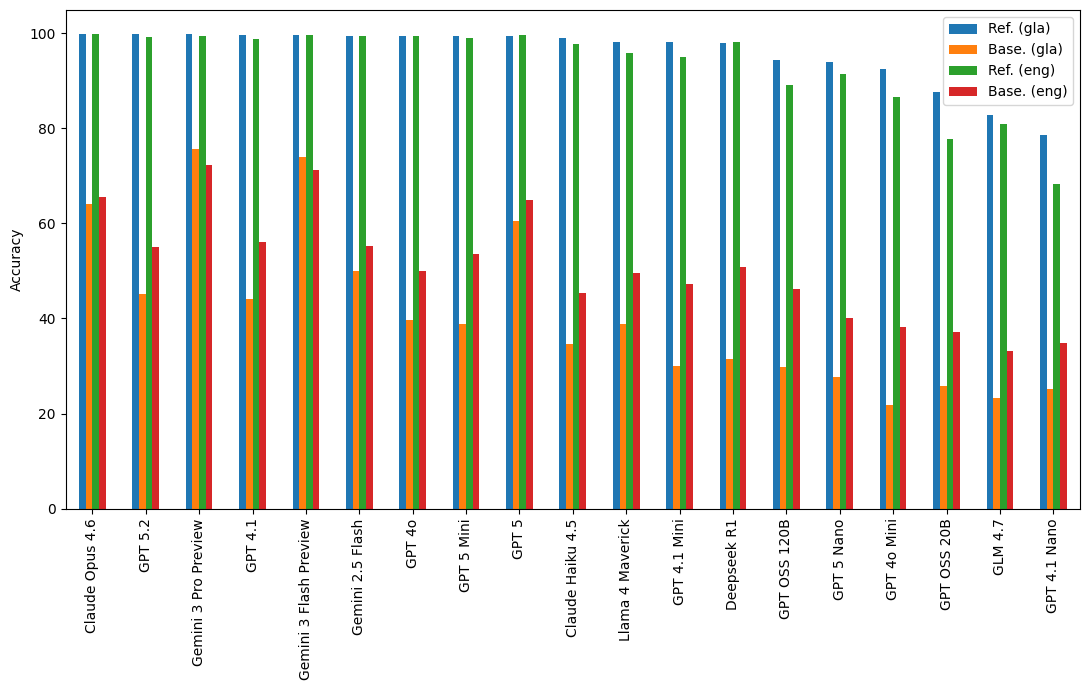

In [ ]:
import matplotlib.pyplot as plt

ax = closed_qa_final_results_df.plot.bar(figsize=(11,7), ylabel="Accuracy")

plt.tight_layout()

plt.savefig('closed_qa_results.pdf')

plt.show()

# Analyze open question answering

In [ ]:
import pandas as pd
from glob import glob

open_qa_aggregate_results = {}

for path in glob("/content/openqa_*.csv"):
    lang = path.split("/")[-1].split(".")[0].split()[-1].split("_")[-1]
    df = pd.read_csv(path)

    model_cols = [c for c in df.columns if c.startswith("single_letter_answer")]

    results = {}
    for model_col in model_cols:
        clean_model_name = model_col.split()[-1]
        if clean_model_name not in model_map.keys():
            continue
        results[model_map[clean_model_name]] = (df[model_col] == df["correct_ans"]).mean()

    open_qa_aggregate_results[lang] = pd.Series(results).T

In [ ]:
open_qa_final_results_df = (pd.DataFrame(open_qa_aggregate_results).sort_values("gd", ascending=False) * 100).round(2)

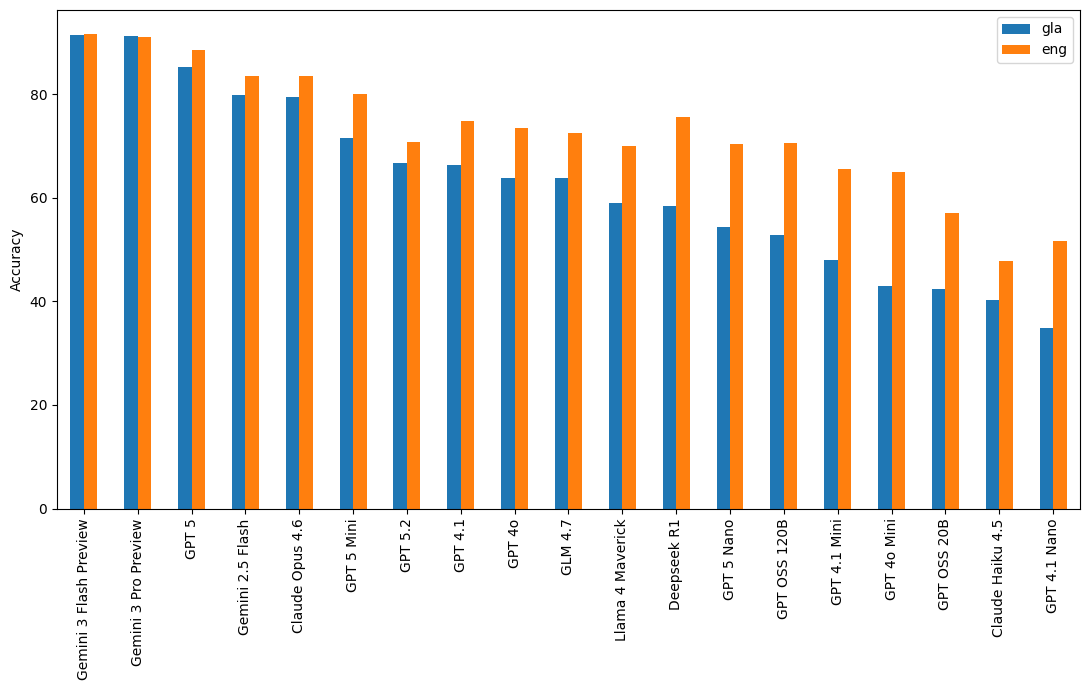

In [ ]:
import matplotlib.pyplot as plt

ax = open_qa_final_results_df.rename({"gd": "gla", "en": "eng"}, axis=1).plot.bar(figsize=(11,7), ylabel="Accuracy")

plt.tight_layout()

plt.savefig('open_qa_results.pdf')

plt.show()

# Manual QA

In [ ]:
import pandas as pd

langs = ["en", "gd"]

manual_qa_aggregate_results = {}


for lang in langs:
    df = pd.read_csv(f"/content/manual_{lang}_qa (1).csv")
    df = df.iloc[[i for i in range(len(df)) if i not in [11, 20, 47]]]

    model_cols = [c for c in df.columns if c != "correct_ans"]
    results = {}
    for model_col in model_cols:
        if model_col not in model_map.keys():
            continue
        results[model_map[model_col]] = (df[model_col] == df["correct_ans"]).mean()

    # results["Gemini 3 Flash Preview"] = None
    manual_qa_aggregate_results[lang] = pd.Series(results).T

In [ ]:
(pd.DataFrame(manual_qa_aggregate_results) * 100).sort_values("gd", ascending=False)

,en,gd
Gemini 3 Pro Preview,80.000000,83.333333
Gemini 3 Flash Preview,77.500000,79.166667
GPT 5,71.666667,69.166667
Gemini 2.5 Flash,62.500000,61.666667
Claude Opus 4.6,50.833333,59.166667
GPT 4o,46.666667,50.000000
Claude Haiku 4.5,43.333333,47.500000
GPT 5 Mini,41.666667,47.500000
Deepseek R1,42.500000,45.000000
Llama 4 Maverick,40.000000,45.000000


In [ ]:
manual_qa_aggregate_results.sort_values(ascending=False) * 100

,0
Gemini 3 Pro Preview,77.500000
Gemini 3 Flash Preview,77.500000
GPT 5,69.166667
Gemini 2.5 Flash,67.500000
Claude Opus 4.6,54.166667
Deepseek R1,43.333333
Claude Haiku 4.5,43.333333
GPT 5 Mini,43.333333
GPT 4.1,40.833333
GPT 4o,40.833333


# Inspect manual QA answers

In [ ]:
from datasets import load_dataset
import pandas as pd


manual_ds = load_dataset(
    "ptrdvn/gaelic-bench",
    "gd-manual-questions",
    split="test",
)
manual_results_df = pd.read_csv("/content/manual_en_qa (1).csv")


README.md: 0.00B [00:00, ?B/s]

gd-manual-questions/test-00000-of-00001.(…):   0%|          | 0.00/18.0k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/123 [00:00<?, ? examples/s]

In [ ]:
manual_ds.add_column(
    "gpt-5-2025-08-07-answers", manual_results_df["gpt-5-2025-08-07"]
).add_column(
    "gemini-3-pro-preview-answers", manual_results_df["gemini-3-pro-preview"]
).to_csv(
    "gaelic_bench_ling_competence_gpt_gemini_answers.csv"
)

Creating CSV from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

19390

# Make heatmap

In [ ]:
from datasets import load_dataset
import pandas as pd


manual_ds = load_dataset(
    "ptrdvn/gaelic-bench",
    "gd-manual-questions",
    split="test",
)
manual_results_df = pd.read_csv("/content/manual_en_qa (1).csv")
manual_results_df = manual_results_df[[c for c in manual_results_df.columns if c in model_map.keys()]]

joined_df = manual_ds.to_pandas().join(
    manual_results_df
)
joined_df["category"] = joined_df["category"].apply(lambda x: x.capitalize())
joined_df = joined_df.iloc[[i for i in range(len(joined_df)) if i not in [11, 20, 47]]]
joined_df = joined_df.reset_index(drop=True)


README.md: 0.00B [00:00, ?B/s]

gd-manual-questions/test-00000-of-00001.(…):   0%|          | 0.00/18.0k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/123 [00:00<?, ? examples/s]

In [ ]:
import io
import pandas as pd
human_results = pd.read_csv(io.StringIO('''
24,27,28,23,26,20,24,24,16,28,28,24,28,23,24,26,26,29,22,29,27,20,25,29,26,28,25,14,22,27,27,28,29,10,24,28,25,28,27,25,27,27,22,17,30,30,30,28,27,10,29,21,21,21,21,21,28,21,29,24,8,29,24,5,24,22,21,25,27,27,28,29,29,28,30,17,6,7,19,7,23,28,26,24,18,16,30,12,16,30,29,29,30,28,28,16,24,25,13,17,23,9,17,30,29,17,17,27,25,25,28,11,28,27,18,27,30,21,21,29
'''), header=None)


In [ ]:
joined_df["is_correct_human"] = human_results.iloc[0, :] / 30

In [ ]:
model_cols = manual_results_df.columns.tolist()
is_correct_cols = ["is_correct_human"]

for model_col in model_cols:
    is_correct_col = f"is_correct_{model_col}"
    joined_df[is_correct_col] = joined_df[model_col] == joined_df["correct_ans"]
    is_correct_cols.append(is_correct_col)

In [ ]:
grouped_df = joined_df.groupby("category")[is_correct_cols].mean()
grouped_df.loc["Mean", :] = joined_df[is_correct_cols].mean()
model_map["human"] = "Human"
clean_cols = [model_map[x[len("is_correct_"):]] for x in is_correct_cols]
grouped_df.columns = clean_cols
no_mean_index = [i for i in grouped_df.index if i != "Mean"]
grouped_df = grouped_df.loc[["Mean"] + no_mean_index]
# num_questions = pd.DataFrame(joined_df.groupby("category").size())
# num_questions.loc["Mean", 0] = int(len(joined_df))
# num_questions[0] = num_questions[0].astype(int)

In [ ]:
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# import seaborn as sns

# # 1. Prepare the figure and the GridSpec
# fig = plt.figure(figsize=(9, 4))
# # FLIPPED: height_ratios=[12, 1] puts the large plot on top
# gs = gridspec.GridSpec(2, 2, height_ratios=[12, 1], width_ratios=[25, 1],
#                        hspace=0, wspace=0.01)

# # 2. Top Row (Now the main Scores heatmap)
# ax1 = plt.subplot(gs[0, 0]) # Index [0, 0] is now the top-left
# cax = plt.subplot(gs[0, 1]) # Colorbar next to the main heatmap

# selected_idx = grouped_df.T.apply(sum, axis=1).sort_values(ascending=False).iloc[:10].index

# sns.heatmap(grouped_df.T.loc[selected_idx], annot=True, fmt=".2f", cmap="Greens", vmin=0, vmax=1,
#             ax=ax1, cbar_ax=cax, cbar_kws={'label': 'Score'})

# ax1.set_xlabel("") # Remove x-label here as it will go on the very bottom
# ax1.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
# ax1.spines['bottom'].set_visible(False) # Removes the line divider
# ax1.set_ylabel("Model", fontsize=12)
# ax1.set_xticks([]) # Hide xticks so it sits flush with the plot below

# # 3. Bottom Row: Number of Questions
# ax0 = plt.subplot(gs[1, 0])

# question_abbrev_map = {'Adjectives': 'ADJ',
#  'Adverbials': 'ADV',
#  'Clefts and focussing expressions': 'CFE',
#  'Colours': 'COL',
#  'Conjunctions and particles': 'CONJ',
#  'Determiners etc': 'DET',
#  'Formulaic expressions and conversation': 'FORM',
#  'Impersonals and passives': 'IPAS',
#  'Nominal mophology': 'NOM',
#  'Numerals': 'NUM',
#  'Prepositions': 'PREP',
#  'Pronouns and anaphor resolution': 'PRO',
#  'Questions and tags': 'QUES',
#  'Relative clauses': 'REL',
#  'Tam system': 'TAM',
#  'Verbal noun cores': 'VNC',
#   'Mean': 'Mean',}

# sns.heatmap(num_questions.T.rename(question_abbrev_map, axis=1), annot=True, fmt="d", cmap=['white'], cbar=False, ax=ax0)

# ax0.set_yticklabels(["Number of questions"], rotation=0)
# ax0.set_xlabel("Category", fontsize=12)
# ax0.set_title("")

# ax1.spines['bottom'].set_visible(False)
# ax0.spines['top'].set_visible(False)

# # Explicitly set the ticks using the dataframe columns
# ax0.set_xticks([x + 0.5 for x in range(len(grouped_df.index))]) # Centers labels
# ax0.set_xticklabels([question_abbrev_map[i] for i in grouped_df.index], rotation=0) #rotation=45, ha='right'
# plt.savefig("aligned_flipped_performance.pdf", bbox_inches='tight')
# plt.show()

/tmp/ipython-input-193/1064667288.py:27: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels = formatted_df.applymap(lambda x: "100" if x == 100 else f"{x:.1f}")


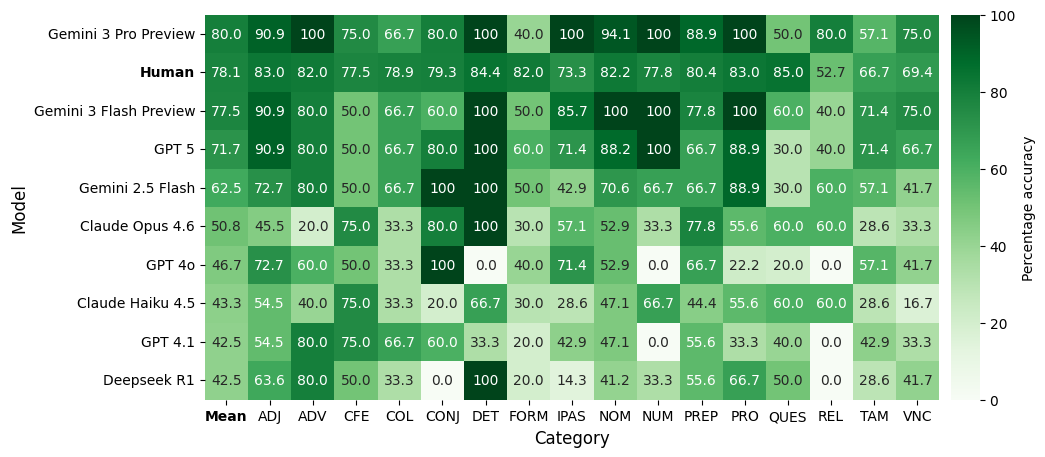

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# 1. Prepare the figure
fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[25, 1], wspace=0.03)

ax1 = plt.subplot(gs[0, 0])
cax = plt.subplot(gs[0, 1])

# 2. Data Selection (Ensure 'Human' is included if it's in your index)
selected_idx = grouped_df.loc["Mean"].sort_values(ascending=False).index[:10]

# 3. Create the formatted DataFrame
question_abbrev_map = {
    'Adjectives': 'ADJ', 'Adverbials': 'ADV', 'Clefts and focussing expressions': 'CFE',
    'Colours': 'COL', 'Conjunctions and particles': 'CONJ', 'Determiners etc': 'DET',
    'Formulaic expressions and conversation': 'FORM', 'Impersonals and passives': 'IPAS',
    'Nominal mophology': 'NOM', 'Numerals': 'NUM', 'Prepositions': 'PREP',
    'Pronouns and anaphor resolution': 'PRO', 'Questions and tags': 'QUES',
    'Relative clauses': 'REL', 'Tam system': 'TAM', 'Verbal noun cores': 'VNC',
    'Mean': 'Mean'
}
formatted_df = grouped_df.T.loc[selected_idx].rename(columns=question_abbrev_map) * 100

annot_labels = formatted_df.applymap(lambda x: "100" if x == 100 else f"{x:.1f}")

sns.heatmap(
    formatted_df,
    annot=annot_labels, # Use our custom labels here
    fmt="",             # Tell seaborn not to apply further formatting
    cmap="Greens",
    vmin=0,
    vmax=100,
    ax=ax1,
    cbar_ax=cax,
    cbar_kws={'label': 'Percentage accuracy'}
)
# # 4. Plot Heatmap
# sns.heatmap(formatted_df, annot=True, fmt=".2f", cmap="Greens", vmin=0, vmax=100,
#             ax=ax1, cbar_ax=cax, cbar_kws={'label': 'Score'})

# 5. Bold specific labels
# Bold "Mean" on the X-axis
for label in ax1.get_xticklabels():
    if label.get_text() == 'Mean':
        label.set_weight('bold')

# Bold "Human" on the Y-axis
for label in ax1.get_yticklabels():
    if label.get_text() == 'Human':
        label.set_weight('bold')

# 6. Final Formatting
ax1.set_ylabel("Model", fontsize=12)
ax1.set_xlabel("Category", fontsize=12)

plt.savefig("performance_bolded.pdf", bbox_inches='tight')
plt.show()

In [ ]:
num_questions.T.rename(question_abbrev_map, axis=1)

NameError: name 'num_questions' is not defined

In [ ]:
num_questions.T.columns

Index(['Adjectives', 'Adverbials', 'Clefts and focussing expressions',
       'Colours', 'Conjunctions and particles', 'Determiners etc',
       'Formulaic expressions and conversation', 'Impersonals and passives',
       'Nominal mophology', 'Numerals', 'Prepositions',
       'Pronouns and anaphor resolution', 'Questions and tags',
       'Relative clauses', 'Tam system', 'Verbal noun cores'],
      dtype='object', name='category')

In [ ]:
abbreviations = [
    'ADJ',   # Adjectives
    'ADV',   # Adverbials
    'CFE',   # Clefts and focussing expressions
    'COL',   # Colours
    'CONJ',  # Conjunctions and particles
    'DET',   # Determiners etc
    'FORM',  # Formulaic expressions and conversation
    'IPAS',  # Impersonals and passives
    'NOM',   # Nominal morphology
    'NUM',   # Numerals
    'PREP',  # Prepositions
    'PRO',   # Pronouns and anaphor resolution
    'QUES',  # Questions and tags
    'REL',   # Relative clauses
    'TAM',   # Tam system
    'VNC'    # Verbal noun cores
]

In [ ]:
{x[1]: x[0] for x in zip(
    abbreviations,
    num_questions.T.columns
)}

{'Adjectives': 'ADJ',
 'Adverbials': 'ADV',
 'Clefts and focussing expressions': 'CFE',
 'Colours': 'COL',
 'Conjunctions and particles': 'CONJ',
 'Determiners etc': 'DET',
 'Formulaic expressions and conversation': 'FORM',
 'Impersonals and passives': 'IPAS',
 'Nominal mophology': 'NOM',
 'Numerals': 'NUM',
 'Prepositions': 'PREP',
 'Pronouns and anaphor resolution': 'PRO',
 'Questions and tags': 'QUES',
 'Relative clauses': 'REL',
 'Tam system': 'TAM',
 'Verbal noun cores': 'VNC'}